In [58]:
from typing import TypedDict, Literal
from langgraph.graph import StateGraph, START, END
from langchain_openrouter import ChatOpenRouter
from langchain_core.messages import SystemMessage, HumanMessage
from pydantic import BaseModel, Field
from dotenv import load_dotenv

In [59]:
load_dotenv()

llm_model = ChatOpenRouter(model="openai/gpt-oss-120b:free")

In [60]:
class ContentSchema(BaseModel):
    feedback: str = Field(description="Feedback about the content. Any strength or weakness that can be improved.")
    approved: bool = Field(description="Is the content good enough to publish or not")

In [61]:
st_model = llm_model.with_structured_output(ContentSchema)

In [62]:
class ContentState(TypedDict):
    topic: str
    max_it: int
    content: str
    feedback: str
    approved: bool
    it: int

In [63]:
def generate_content(state: ContentState) -> ContentState:
    topic = state['topic']

    messages = [
        SystemMessage(content="You're a poor content writer."),
        HumanMessage(content=f'''
Write a poor article/content on the provided topic.

Topic: {topic}

Note: Do not exceed 200 words.
''')
]
    
    state['content'] = llm_model.invoke(messages).content

    return state

In [64]:
def evaluate_content(state: ContentState) -> ContentState:
    topic = state['topic']
    content = state['content']

    messages = [SystemMessage(content="You're an experienced content evaluator"),
                HumanMessage(content=f'''Evaluate the content for the given topic.
- Topic: {topic}
- Content: {content}
''')]
    
    evaluation = st_model.invoke(messages)

    state['feedback'] = evaluation.feedback
    state['approved'] = evaluation.approved

    return state

In [65]:
def optimize_content(state: ContentState):
    it = state['it']
    it+=1

    topic = state['topic']
    prior_content = state['content']
    feedback = state['feedback']

    messages = [
        SystemMessage(content="You're an experienced content optimizer on the basis of feedback."),
        HumanMessage(content=f'''You're given a topic and content about it, you have to optimize the prior/original content on the basis of provided feedback.
- Topic: {topic}
- Prior/original content: {prior_content}
- Feedback: {feedback}
''')]
    
    new_content = llm_model.invoke(messages).content

    state['content'] = new_content
    state['it'] = it
 
    return state

In [66]:
def content_approved(state: ContentState):
    approved = state['approved']
    it = state['it']
    max_it = state['max_it']

    if approved or it >= max_it:
        return True
    else:
        return False

In [67]:
graph = StateGraph(ContentState)

graph.add_node('generate_content', generate_content)
graph.add_node('evaluate_content', evaluate_content)
graph.add_node('optimize_content', optimize_content)

graph.add_edge(START, 'generate_content')
graph.add_edge('generate_content', 'evaluate_content')
graph.add_conditional_edges('evaluate_content', content_approved, {True: END, False: 'optimize_content'})
graph.add_edge('optimize_content', 'evaluate_content')

workflow = graph.compile()

In [68]:
input_state = {'topic': 'Artificial Intelligence in Healthcare', 'max_it': 3, 'it': 0}
output_state = workflow.invoke(input_state)

print(output_state)

{'topic': 'Artificial Intelligence in Healthcare', 'max_it': 3, 'content': '### Artificial Intelligence in Healthcare: Opportunities, Challenges, and the Road Ahead  \n\n#### Introduction  \nArtificial intelligence (AI) – the set of computational techniques that enable machines to perceive, reason, learn, and act autonomously – is rapidly moving from research laboratories into clinical practice. From diagnostic imaging to drug discovery, AI‑driven tools are reshaping how health‑care providers collect, interpret, and act on medical data. This review summarizes the most mature applications, evaluates the evidence for clinical benefit, and discusses the ethical, regulatory, and operational challenges that must be addressed for sustainable adoption.\n\n#### 1. Core Areas of AI Deployment  \n\n| Clinical Domain | Representative AI Technologies | Typical Use Cases | Evidence of Impact* |\n|----------------|--------------------------------|-------------------|---------------------|\n| **Medic

In [69]:
print(output_state['topic'])
print(output_state['it'])
print(output_state['feedback'])
print(output_state['approved'])
print(output_state['content'])

Artificial Intelligence in Healthcare
1
The content provides a comprehensive, well-structured overview of AI in healthcare. It covers core application areas with evidence, clearly outlines benefits, challenges, ethical considerations, and future directions, and includes credible references. Minor improvements: add more recent 2025-2026 studies if available, and clarify the distinction between AI‑enabled tools and full automation. Overall, it is ready for publication.
True
### Artificial Intelligence in Healthcare: Opportunities, Challenges, and the Road Ahead  

#### Introduction  
Artificial intelligence (AI) – the set of computational techniques that enable machines to perceive, reason, learn, and act autonomously – is rapidly moving from research laboratories into clinical practice. From diagnostic imaging to drug discovery, AI‑driven tools are reshaping how health‑care providers collect, interpret, and act on medical data. This review summarizes the most mature applications, evalua

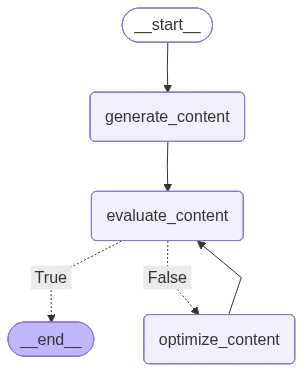

In [70]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())